# NVIDIA GPU Sales & Market Dynamics Analysis

This notebook performs data cleaning, validation, feature engineering, and exploratory data analysis (EDA) on a synthetic NVIDIA GPU sales dataset.

> **Note:** This project uses synthetic data created for portfolio and analytical practice. The findings represent patterns within the simulated dataset and should not be interpreted as actual NVIDIA sales performance.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

# File path
DATA_PATH = Path("nvidia_gpu_sales_synthetic_2026_RAW.csv")

# Load dataset
df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded successfully.")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

Dataset loaded successfully.
Rows    : 7,000
Columns : 17


## 2. Data Quality Assessment

This section evaluates the dataset for missing values, duplicate records, duplicate transaction IDs, data types, and basic data consistency before the cleaning process.

In [3]:
# Dataset preview
df.head()

,sale_id,sale_date,gpu_model,gpu_family,launch_year,region,sales_channel,customer_segment,units_sold,msrp_usd,avg_street_price_usd,price_premium_pct,stock_status,customer_satisfaction_score,warranty_months,bundle_addon,revenue_usd
0,1,2024-01-12,RTX 4090,Consumer Gaming,2022,Asia-Pacific (ex-China),Retail/Etail,Gaming,8,1599,"1,796.91",12.38,Low Stock,4.00,12,Software Bundle,"14,375.30"
1,2,2024-01-18,RTX 4070 Ti Super,Consumer Gaming,2024,Asia-Pacific (ex-China),System Integrator/OEM,Content Creation,34,799,964.70,20.74,Low Stock,5.00,12,NaN,"32,799.82"
2,3,2024-01-20,RTX 4080 Super,Consumer Gaming,2024,North America,Retail/Etail,Gaming,30,999,"1,308.25",30.96,Sold Out,4.00,12,NaN,"39,247.64"
3,4,2024-02-05,H100 SXM,Data Center AI,2022,Asia-Pacific (ex-China),Direct Enterprise,Crypto Mining,5,27000,"29,202.11",8.16,Low Stock,4.50,24,NaN,"146,010.54"
4,5,2024-02-16,H100 SXM,Data Center AI,2022,Europe,Cloud Provider,Crypto Mining,9,27000,"27,778.73",2.88,In Stock,4.50,36,NaN,"250,008.56"


In [4]:
# Dataset structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   sale_id                      7000 non-null   int64  
 1   sale_date                    7000 non-null   object 
 2   gpu_model                    7000 non-null   object 
 3   gpu_family                   7000 non-null   object 
 4   launch_year                  7000 non-null   int64  
 5   region                       7000 non-null   object 
 6   sales_channel                7000 non-null   object 
 7   customer_segment             7000 non-null   object 
 8   units_sold                   7000 non-null   int64  
 9   msrp_usd                     7000 non-null   int64  
 10  avg_street_price_usd         7000 non-null   float64
 11  price_premium_pct            7000 non-null   float64
 12  stock_status                 7000 non-null   object 
 13  customer_satisfact

In [5]:
# Missing value summary
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_summary = missing_summary[
    missing_summary["missing_count"] > 0
].sort_values("missing_count", ascending=False)

missing_summary

,missing_count,missing_percentage
bundle_addon,3841,54.87


In [6]:
# Check duplicate rows
duplicate_rows = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_rows:,}")

Duplicate rows: 0


In [7]:
# Check duplicate transaction IDs
duplicate_sale_ids = df["sale_id"].duplicated().sum()

print(f"Duplicate sale IDs: {duplicate_sale_ids:,}")

Duplicate sale IDs: 0


In [8]:
# Descriptive statistics for numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
sale_id,"7,000.00","3,500.50","2,020.87",1.00,"1,750.75","3,500.50","5,250.25","7,000.00"
launch_year,"7,000.00","2,024.26",1.10,"2,020.00","2,024.00","2,025.00","2,025.00","2,025.00"
units_sold,"7,000.00",21.67,12.93,1.00,12.00,20.00,29.00,104.00
msrp_usd,"7,000.00","5,212.90","11,056.78",549.00,749.00,999.00,"1,599.00","42,000.00"
avg_street_price_usd,"7,000.00","6,042.14","12,976.95",549.05,805.09,"1,048.01","2,002.57","82,364.48"
price_premium_pct,"7,000.00",15.01,14.35,0.00,4.56,8.85,21.35,98.46
customer_satisfaction_score,"7,000.00",4.43,0.61,1.50,4.00,4.50,5.00,5.00
warranty_months,"7,000.00",19.75,8.64,12.00,12.00,24.00,24.00,36.00
revenue_usd,"7,000.00","56,580.06","99,962.69","1,393.13","15,551.33","25,342.93","46,706.57","1,225,725.66"


## 3. Data Cleaning

This section handles missing values, converts data types, and standardizes categorical text fields to prepare the dataset for analysis.

In [9]:
# Create a copy for the cleaning process
df_clean = df.copy()

In [10]:
# Replace missing bundle add-ons with "Standalone"
df_clean["bundle_addon"] = df_clean["bundle_addon"].fillna("Standalone")

In [11]:
df_clean["bundle_addon"].value_counts(dropna=False)

,count
bundle_addon,
Standalone,3841
Extended Warranty,1166
Software Bundle,859
Cooling Kit,598
Support Contract,368
NVLink Cluster Install,168


In [12]:
# Convert sale_date to datetime
df_clean["sale_date"] = pd.to_datetime(
    df_clean["sale_date"],
    errors="coerce"
)

In [13]:
print("Invalid dates:", df_clean["sale_date"].isna().sum())
print("Data type:", df_clean["sale_date"].dtype)

Invalid dates: 0
Data type: datetime64[ns]


In [14]:
# Remove leading/trailing whitespace from categorical columns
categorical_columns = [
    "gpu_model",
    "gpu_family",
    "region",
    "sales_channel",
    "customer_segment",
    "stock_status",
    "bundle_addon"
]

for column in categorical_columns:
    df_clean[column] = df_clean[column].str.strip()

In [15]:
# Validate cleaning results
print(f"Remaining missing values : {df_clean.isnull().sum().sum():,}")
print(f"Duplicate rows          : {df_clean.duplicated().sum():,}")
print(f"Duplicate sale IDs      : {df_clean['sale_id'].duplicated().sum():,}")
print(f"Dataset shape           : {df_clean.shape}")

Remaining missing values : 0
Duplicate rows          : 0
Duplicate sale IDs      : 0
Dataset shape           : (7000, 17)


## 4. Feature Engineering

This section creates derived features that support deeper analysis. Price premium percentages are grouped into interpretable scalping categories based on predefined thresholds.

In [16]:
# Categorize price premiums into scalping status groups
df_clean["scalping_status"] = pd.cut(
    df_clean["price_premium_pct"],
    bins=[-np.inf, 5, 20, np.inf],
    labels=["Normal MSRP", "Slight Premium", "Heavy Scalping"],
    include_lowest=True
)

In [17]:
# Check scalping category distribution
scalping_distribution = (
    df_clean["scalping_status"]
    .value_counts()
    .reindex(["Normal MSRP", "Slight Premium", "Heavy Scalping"])
)

scalping_distribution

,count
scalping_status,
Normal MSRP,1921
Slight Premium,3113
Heavy Scalping,1966


In [18]:
scalping_distribution.sum()

np.int64(7000)

In [19]:
# Validate premium ranges for each scalping category
df_clean.groupby(
    "scalping_status",
    observed=True
)["price_premium_pct"].agg(["count", "min", "max"])

,count,min,max
scalping_status,,,
Normal MSRP,1921,0.00,5.00
Slight Premium,3113,5.01,20.00
Heavy Scalping,1966,20.01,98.46


## 5. Exploratory Data Analysis

This section explores the main patterns in the cleaned dataset, including sales performance, revenue distribution, pricing behavior, customer satisfaction, and market dynamics across products, regions, and customer segments.

### 5.1 Overall Business Overview

This section summarizes the overall scale of the simulated sales dataset using key transaction, sales, revenue, pricing, and customer satisfaction metrics.

In [20]:
# Overall business overview
overview = pd.Series({
    "Total Transactions": len(df_clean),
    "Total Units Sold": df_clean["units_sold"].sum(),
    "Total Revenue (USD)": df_clean["revenue_usd"].sum(),
    "Average Revenue per Transaction (USD)": df_clean["revenue_usd"].mean(),
    "Average Price Premium (%)": df_clean["price_premium_pct"].mean(),
    "Average Customer Satisfaction": df_clean["customer_satisfaction_score"].mean()
})

overview

,0
Total Transactions,"7,000.00"
Total Units Sold,"151,719.00"
Total Revenue (USD),"396,060,452.63"
Average Revenue per Transaction (USD),"56,580.06"
Average Price Premium (%),15.01
Average Customer Satisfaction,4.43


In [21]:
gpu_family_summary = (
    df_clean
    .groupby("gpu_family")
    .agg(
        total_transactions=("sale_id", "count"),
        total_units_sold=("units_sold", "sum"),
        total_revenue_usd=("revenue_usd", "sum")
    )
    .sort_values("total_revenue_usd", ascending=False)
)

gpu_family_summary

,total_transactions,total_units_sold,total_revenue_usd
gpu_family,,,
Data Center AI,1077,7027,"233,110,736.39"
Consumer Gaming,5923,144692,"162,949,716.24"


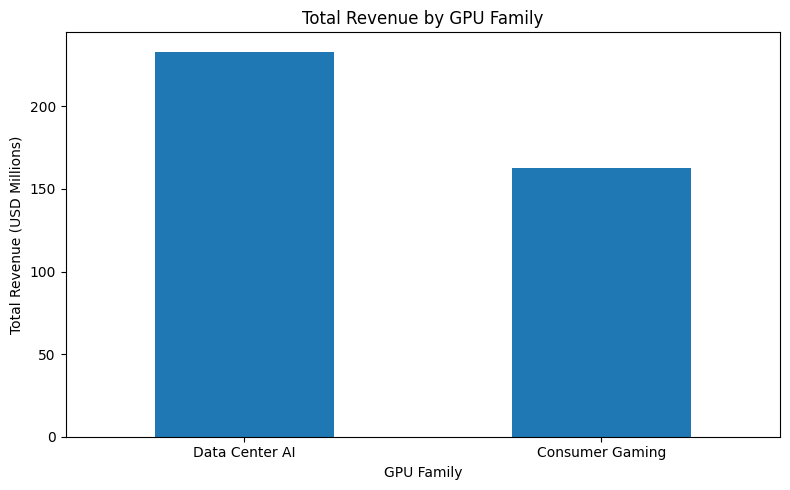

In [23]:
# Total revenue by GPU family (USD millions)
gpu_family_revenue_m = gpu_family_revenue / 1_000_000

plt.figure(figsize=(8, 5))

gpu_family_revenue_m.plot(kind="bar")

plt.title("Total Revenue by GPU Family")
plt.xlabel("GPU Family")
plt.ylabel("Total Revenue (USD Millions)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

**Key Finding:**  
Although Consumer Gaming accounts for substantially higher unit sales, Data Center AI generates greater total revenue. This reflects the substantially higher transaction value associated with enterprise-oriented GPU products in the simulated dataset.

### 5.2 Product Performance

This section compares individual GPU models based on transaction volume, units sold, revenue contribution, pricing, and customer satisfaction.

In [24]:
# Product performance summary
gpu_model_summary = (
    df_clean
    .groupby(["gpu_model", "gpu_family"])
    .agg(
        total_transactions=("sale_id", "count"),
        total_units_sold=("units_sold", "sum"),
        total_revenue_usd=("revenue_usd", "sum"),
        avg_street_price_usd=("avg_street_price_usd", "mean"),
        avg_price_premium_pct=("price_premium_pct", "mean"),
        avg_customer_satisfaction=("customer_satisfaction_score", "mean")
    )
    .reset_index()
)

gpu_model_summary[
    [
        "avg_street_price_usd",
        "avg_price_premium_pct",
        "avg_customer_satisfaction"
    ]
] = gpu_model_summary[
    [
        "avg_street_price_usd",
        "avg_price_premium_pct",
        "avg_customer_satisfaction"
    ]
].round(2)

gpu_model_summary.sort_values(
    "total_units_sold",
    ascending=False
)

,gpu_model,gpu_family,total_transactions,total_units_sold,total_revenue_usd,avg_street_price_usd,avg_price_premium_pct,avg_customer_satisfaction
8,RTX 5070,Consumer Gaming,1268,30454,"19,168,684.60",628.86,14.55,4.41
9,RTX 5070 Ti,Consumer Gaming,1059,26361,"22,679,968.64",860.71,14.91,4.38
5,RTX 4070 Ti Super,Consumer Gaming,937,22944,"21,027,516.56",916.58,14.72,4.43
10,RTX 5080,Consumer Gaming,841,20419,"23,502,943.44","1,145.65",14.68,4.41
6,RTX 4080 Super,Consumer Gaming,676,16672,"19,218,660.27","1,148.85",15.00,4.36
7,RTX 4090,Consumer Gaming,580,13930,"25,550,436.91","1,841.05",15.14,4.37
11,RTX 5090,Consumer Gaming,562,13912,"31,801,505.82","2,295.08",14.81,4.41
1,B200,Data Center AI,305,1943,"95,930,594.39","48,959.15",16.57,4.59
3,H200,Data Center AI,250,1646,"65,758,987.10","40,162.23",14.75,4.59
2,H100 SXM,Data Center AI,214,1461,"46,083,716.98","31,414.87",16.35,4.58


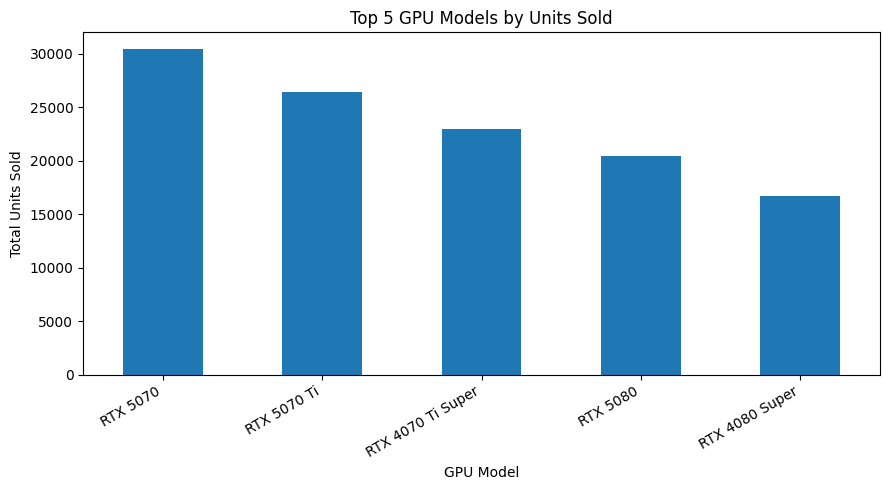

In [25]:
# Top 5 GPU models by units sold
top5_units = (
    gpu_model_summary
    .nlargest(5, "total_units_sold")
    .set_index("gpu_model")["total_units_sold"]
)

plt.figure(figsize=(9, 5))

top5_units.plot(kind="bar")

plt.title("Top 5 GPU Models by Units Sold")
plt.xlabel("GPU Model")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.show()

**Key Finding:**  
RTX 5070 recorded the highest total unit sales among all GPU models in the simulated dataset. However, high sales volume does not necessarily correspond to the highest revenue contribution, as product prices vary substantially across models.

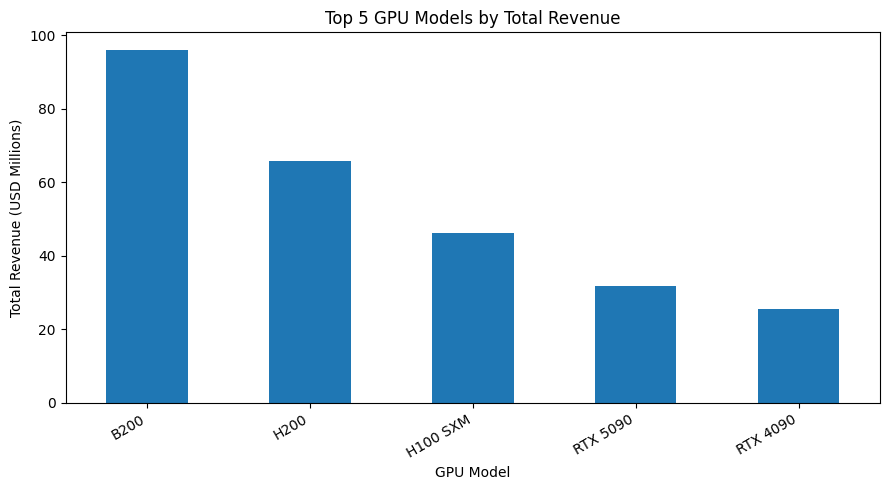

In [26]:
# Top 5 GPU models by total revenue
top5_revenue = (
    gpu_model_summary
    .nlargest(5, "total_revenue_usd")
    .copy()
)

top5_revenue["total_revenue_musd"] = (
    top5_revenue["total_revenue_usd"] / 1_000_000
)

top5_revenue = top5_revenue.set_index("gpu_model")

plt.figure(figsize=(9, 5))

top5_revenue["total_revenue_musd"].plot(kind="bar")

plt.title("Top 5 GPU Models by Total Revenue")
plt.xlabel("GPU Model")
plt.ylabel("Total Revenue (USD Millions)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.show()

**Key Finding:**  
B200 generated the highest total revenue at approximately $95.9 million, followed by H200 and H100 SXM. Unlike the unit-sales ranking, the revenue ranking is dominated by Data Center AI GPUs, showing that lower sales volume can still generate substantially higher revenue when products have significantly higher unit prices. This highlights the difference between sales volume leadership and revenue contribution within the simulated dataset.

### 5.3 Regional Performance

This section compares regional market performance based on transaction volume, units sold, total revenue, and average price premium.

In [27]:
# Regional performance summary
regional_summary = (
    df_clean
    .groupby("region")
    .agg(
        total_transactions=("sale_id", "count"),
        total_units_sold=("units_sold", "sum"),
        total_revenue_usd=("revenue_usd", "sum"),
        avg_price_premium_pct=("price_premium_pct", "mean"),
        avg_customer_satisfaction=("customer_satisfaction_score", "mean")
    )
    .reset_index()
)

regional_summary[
    ["avg_price_premium_pct", "avg_customer_satisfaction"]
] = regional_summary[
    ["avg_price_premium_pct", "avg_customer_satisfaction"]
].round(2)

regional_summary.sort_values(
    "total_revenue_usd",
    ascending=False
)

,region,total_transactions,total_units_sold,total_revenue_usd,avg_price_premium_pct,avg_customer_satisfaction
3,North America,2248,48926,"121,370,200.03",14.68,4.44
2,Europe,1689,36755,"91,113,060.65",14.98,4.41
0,Asia-Pacific (ex-China),1445,31288,"88,665,305.35",15.00,4.43
1,China,1072,23362,"64,605,452.82",15.97,4.41
4,Rest of World,546,11388,"30,306,433.78",14.62,4.45


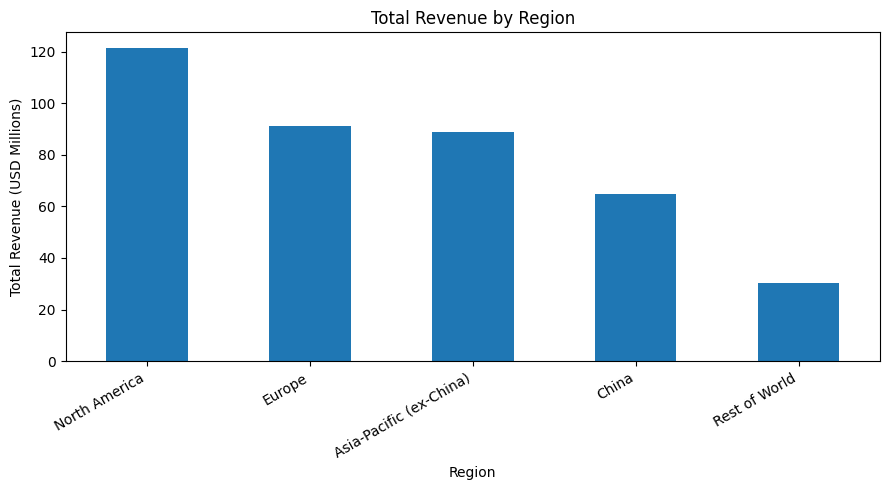

In [28]:
# Total revenue by region
region_revenue = (
    regional_summary
    .sort_values("total_revenue_usd", ascending=False)
    .copy()
)

region_revenue["total_revenue_musd"] = (
    region_revenue["total_revenue_usd"] / 1_000_000
)

region_revenue = region_revenue.set_index("region")

plt.figure(figsize=(9, 5))

region_revenue["total_revenue_musd"].plot(kind="bar")

plt.title("Total Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Total Revenue (USD Millions)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.show()

**Key Finding:**  
North America generated the highest total revenue in the simulated dataset, followed by Europe and Asia-Pacific (ex-China). The regional revenue ranking is broadly aligned with transaction and sales volume, indicating that North America represents the largest simulated market by overall activity.

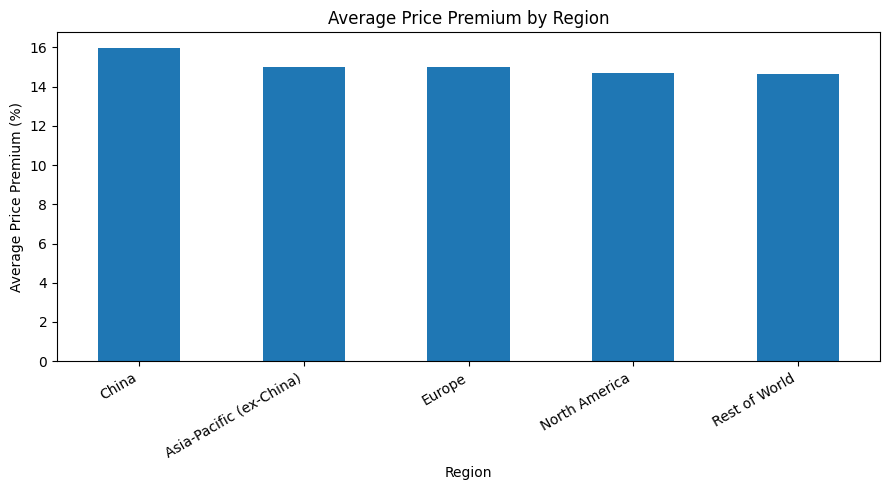

In [29]:
# Average price premium by region
region_premium = (
    regional_summary
    .sort_values("avg_price_premium_pct", ascending=False)
    .set_index("region")["avg_price_premium_pct"]
)

plt.figure(figsize=(9, 5))

region_premium.plot(kind="bar")

plt.title("Average Price Premium by Region")
plt.xlabel("Region")
plt.ylabel("Average Price Premium (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.show()

**Key Finding:**  
China recorded the highest average price premium at approximately 15.97%. However, the differences across regions were relatively small, with all regional averages falling within a narrow range of roughly 14.6% to 16.0%. This suggests that premium pricing is fairly consistent across regions in the simulated dataset.

### 5.4 Pricing, Scalping & Customer Satisfaction

This section explores the relationship between price premiums, scalping categories, and customer satisfaction. The analysis focuses on identifying patterns and associations within the simulated dataset rather than making causal claims.

In [32]:
# Correlation between price premium and customer satisfaction
premium_satisfaction_corr = df_clean[
    ["price_premium_pct", "customer_satisfaction_score"]
].corr()

premium_satisfaction_corr

,price_premium_pct,customer_satisfaction_score
price_premium_pct,1.00,-0.67
customer_satisfaction_score,-0.67,1.00


In [31]:
corr_value = df_clean[
    "price_premium_pct"
].corr(
    df_clean["customer_satisfaction_score"]
)

print(
    f"Correlation between price premium and customer satisfaction: "
    f"{corr_value:.3f}"
)

Correlation between price premium and customer satisfaction: -0.672


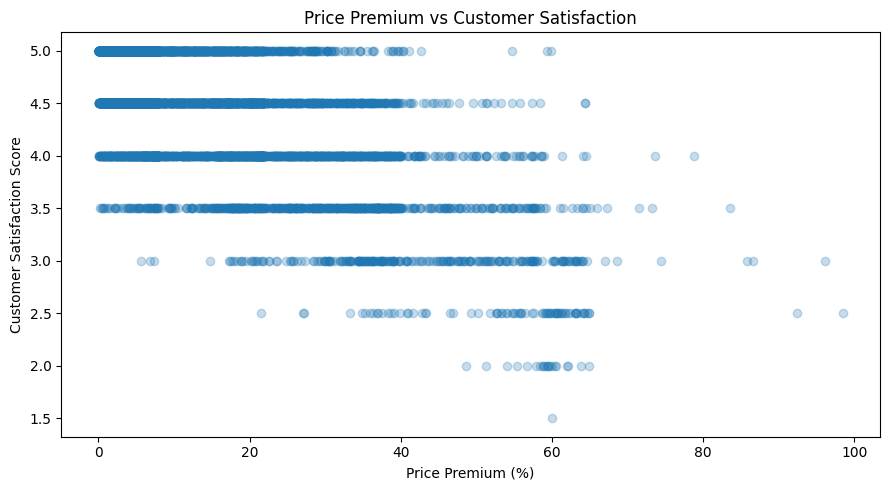

In [33]:
plt.figure(figsize=(9, 5))

plt.scatter(
    df_clean["price_premium_pct"],
    df_clean["customer_satisfaction_score"],
    alpha=0.25
)

plt.title("Price Premium vs Customer Satisfaction")
plt.xlabel("Price Premium (%)")
plt.ylabel("Customer Satisfaction Score")
plt.tight_layout()

plt.show()

**Key Finding:**  
Customer satisfaction generally declines as price premiums increase. The scatter plot shows a negative relationship between premium pricing and satisfaction within the simulated dataset. This pattern should be interpreted as an association rather than evidence of causality.

In [34]:
scalping_summary = (
    df_clean
    .groupby("scalping_status", observed=True)
    .agg(
        total_transactions=("sale_id", "count"),
        avg_price_premium_pct=("price_premium_pct", "mean"),
        avg_customer_satisfaction=("customer_satisfaction_score", "mean")
    )
    .reindex([
        "Normal MSRP",
        "Slight Premium",
        "Heavy Scalping"
    ])
    .round(2)
)

scalping_summary

,total_transactions,avg_price_premium_pct,avg_customer_satisfaction
scalping_status,,,
Normal MSRP,1921,2.48,4.76
Slight Premium,3113,10.66,4.57
Heavy Scalping,1966,34.14,3.88


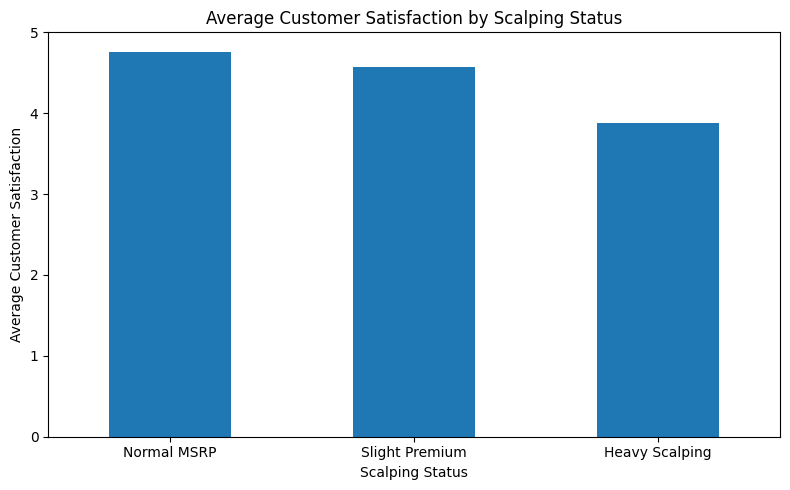

In [35]:
scalping_satisfaction = (
    scalping_summary["avg_customer_satisfaction"]
)

plt.figure(figsize=(8, 5))

scalping_satisfaction.plot(kind="bar")

plt.title("Average Customer Satisfaction by Scalping Status")
plt.xlabel("Scalping Status")
plt.ylabel("Average Customer Satisfaction")
plt.xticks(rotation=0)
plt.ylim(0, 5)
plt.tight_layout()

plt.show()

**Key Finding:**  
Normal MSRP transactions recorded the highest average customer satisfaction, while Heavy Scalping transactions recorded the lowest. Average satisfaction declined progressively across higher premium categories, reinforcing the negative association observed between price premiums and customer satisfaction.

### 5.5 Stock Availability & Market Pressure

This section examines how stock availability is associated with price premiums and customer satisfaction within the simulated market.

In [36]:
stock_summary = (
    df_clean
    .groupby("stock_status")
    .agg(
        total_transactions=("sale_id", "count"),
        avg_price_premium_pct=("price_premium_pct", "mean"),
        avg_customer_satisfaction=("customer_satisfaction_score", "mean")
    )
    .reindex([
        "In Stock",
        "Low Stock",
        "Backordered",
        "Sold Out"
    ])
    .round(2)
)

stock_summary

,total_transactions,avg_price_premium_pct,avg_customer_satisfaction
stock_status,,,
In Stock,3117,4.07,4.73
Low Stock,1946,13.86,4.49
Backordered,1268,27.89,4.08
Sold Out,669,44.95,3.52


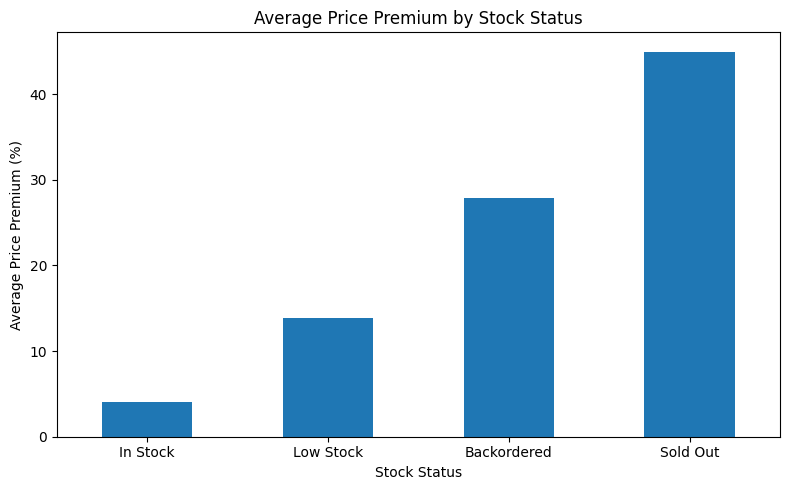

In [37]:
plt.figure(figsize=(8, 5))

stock_summary["avg_price_premium_pct"].plot(kind="bar")

plt.title("Average Price Premium by Stock Status")
plt.xlabel("Stock Status")
plt.ylabel("Average Price Premium (%)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

**Key Finding:**  
Average price premiums increase substantially as product availability becomes more constrained. In-stock products recorded an average premium of approximately 4%, while sold-out products approached 45%, indicating a strong association between scarcity and premium pricing within the simulated dataset.

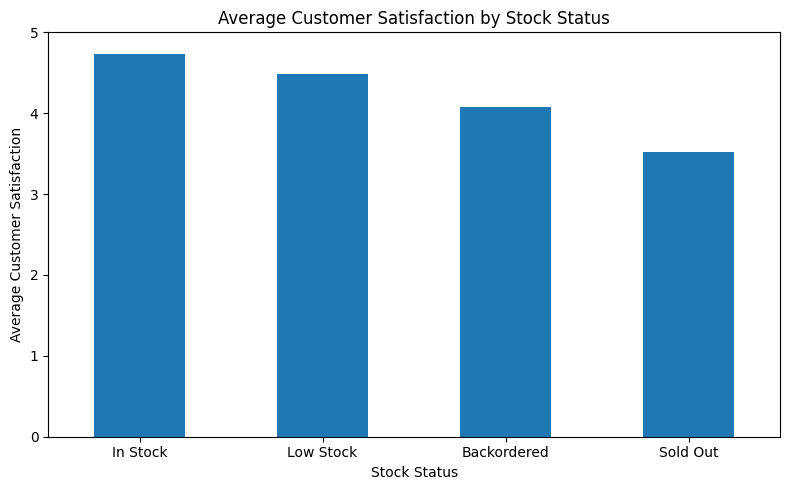

In [38]:
plt.figure(figsize=(8, 5))

stock_summary["avg_customer_satisfaction"].plot(kind="bar")

plt.title("Average Customer Satisfaction by Stock Status")
plt.xlabel("Stock Status")
plt.ylabel("Average Customer Satisfaction")
plt.xticks(rotation=0)
plt.ylim(0, 5)
plt.tight_layout()

plt.show()

**Key Finding:**  
Customer satisfaction declines progressively as stock availability worsens. In-stock products recorded the highest average satisfaction at approximately 4.73, while sold-out products recorded the lowest at approximately 3.52.

### 5.6 Customer Segments & Sales Channels

This section examines differences in transaction value across customer segments and sales channels, and explores how product mix contributes to revenue performance.

In [39]:
# Customer segment performance
customer_segment_summary = (
    df_clean
    .groupby("customer_segment")
    .agg(
        total_transactions=("sale_id", "count"),
        total_units_sold=("units_sold", "sum"),
        avg_units_per_transaction=("units_sold", "mean"),
        total_revenue_usd=("revenue_usd", "sum"),
        avg_revenue_per_transaction=("revenue_usd", "mean")
    )
    .round(2)
    .sort_values("avg_revenue_per_transaction", ascending=False)
)

customer_segment_summary

,total_transactions,total_units_sold,avg_units_per_transaction,total_revenue_usd,avg_revenue_per_transaction
customer_segment,,,,,
Crypto Mining,179,1232,6.88,"43,981,371.53","245,705.99"
Hyperscale Datacenter,584,3834,6.57,"127,612,499.27","218,514.55"
AI Research/Startup,314,1961,6.25,"61,516,865.59","195,913.58"
Content Creation,1161,28093,24.20,"32,635,583.04","28,109.89"
Gaming,4762,116599,24.49,"130,314,133.20","27,365.42"


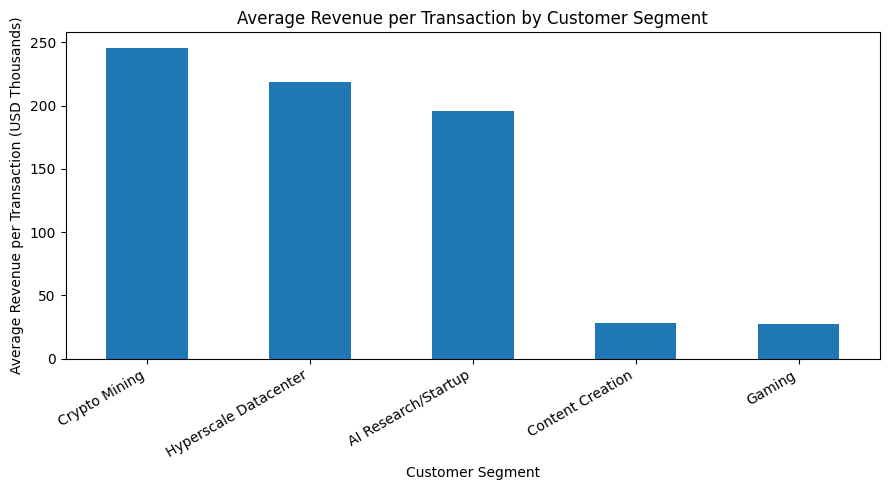

In [40]:
# Average revenue per transaction by customer segment
segment_avg_revenue = (
    customer_segment_summary["avg_revenue_per_transaction"]
    / 1_000
)

plt.figure(figsize=(9, 5))

segment_avg_revenue.plot(kind="bar")

plt.title("Average Revenue per Transaction by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Revenue per Transaction (USD Thousands)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.show()

**Key Finding:**  
Enterprise-oriented customer segments generated substantially higher average revenue per transaction than Gaming and Content Creation. This difference remains notable even though enterprise transactions generally contain fewer units, indicating that transaction value is strongly influenced by the higher-priced product mix within the simulated dataset.

In [41]:
# Sales channel performance
sales_channel_summary = (
    df_clean
    .groupby("sales_channel")
    .agg(
        total_transactions=("sale_id", "count"),
        total_units_sold=("units_sold", "sum"),
        total_revenue_usd=("revenue_usd", "sum"),
        avg_revenue_per_transaction=("revenue_usd", "mean")
    )
    .round(2)
    .sort_values("total_revenue_usd", ascending=False)
)

sales_channel_summary

,total_transactions,total_units_sold,total_revenue_usd,avg_revenue_per_transaction
sales_channel,,,,
Retail/Etail,4459,108131,"121,603,224.99","27,271.41"
Cloud Provider,530,3520,"112,399,919.33","212,075.32"
Direct Enterprise,370,2426,"83,950,257.25","226,892.59"
System Integrator/OEM,1641,37642,"78,107,051.06","47,597.23"


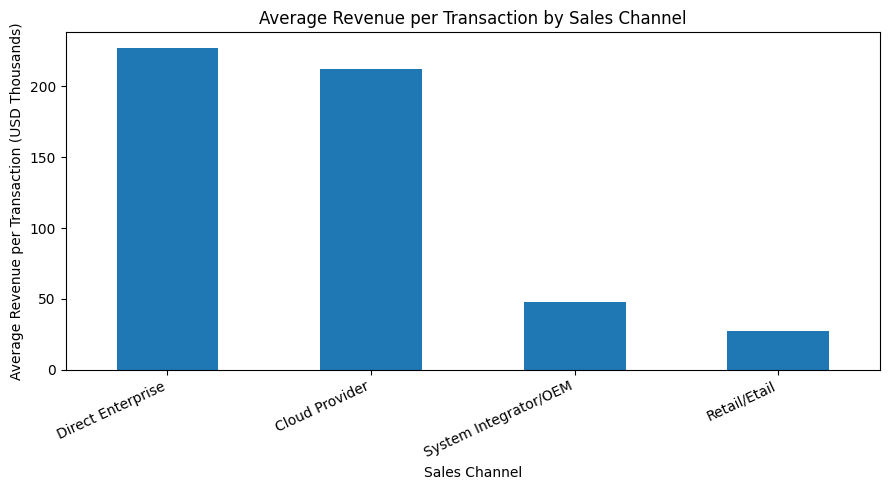

In [42]:
# Average transaction value by sales channel
channel_avg_revenue = (
    sales_channel_summary
    .sort_values("avg_revenue_per_transaction", ascending=False)
    ["avg_revenue_per_transaction"]
    / 1_000
)

plt.figure(figsize=(9, 5))

channel_avg_revenue.plot(kind="bar")

plt.title("Average Revenue per Transaction by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Average Revenue per Transaction (USD Thousands)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

plt.show()

**Key Finding:**  
Sales channels differ substantially in average transaction value. Enterprise-oriented channels can generate high revenue from relatively few transactions, while Retail/Etail relies more heavily on transaction and unit volume. This suggests that channel performance should be evaluated using both volume and transaction value rather than total revenue alone.

In [43]:
# Revenue composition by sales channel and GPU family
channel_family_revenue = pd.pivot_table(
    df_clean,
    index="sales_channel",
    columns="gpu_family",
    values="revenue_usd",
    aggfunc="sum",
    fill_value=0
)

channel_family_revenue

gpu_family,Consumer Gaming,Data Center AI
sales_channel,,
Cloud Provider,0.00,"112,399,919.33"
Direct Enterprise,0.00,"83,950,257.25"
Retail/Etail,"121,603,224.99",0.00
System Integrator/OEM,"41,346,491.25","36,760,559.81"


<Figure size 900x500 with 0 Axes>

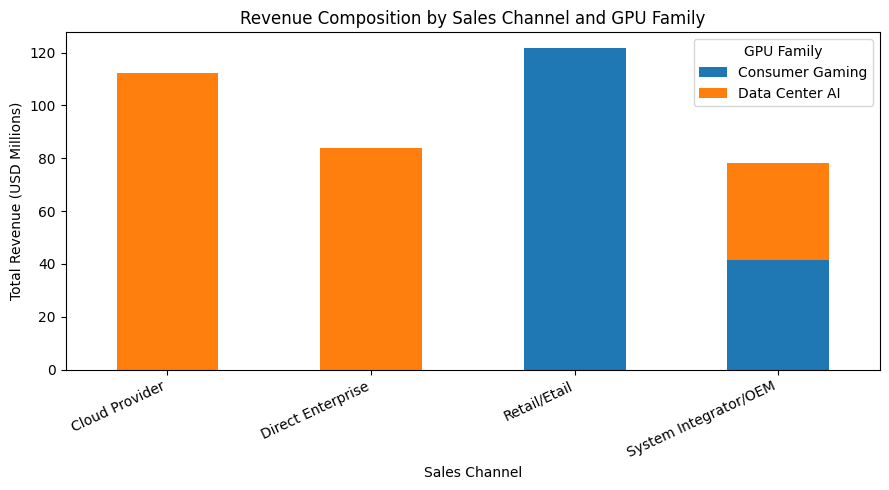

In [44]:
channel_family_revenue_m = (
    channel_family_revenue / 1_000_000
)

plt.figure(figsize=(9, 5))

channel_family_revenue_m.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.title("Revenue Composition by Sales Channel and GPU Family")
plt.xlabel("Sales Channel")
plt.ylabel("Total Revenue (USD Millions)")
plt.xticks(rotation=25, ha="right")
plt.legend(title="GPU Family")
plt.tight_layout()

plt.show()

**Key Finding:**  
Sales channels show a clear difference in product mix. Cloud Provider and Direct Enterprise revenue comes entirely from Data Center AI products, while Retail/Etail revenue is fully driven by Consumer Gaming GPUs. System Integrator/OEM serves both product families. This product mix helps explain why enterprise-oriented channels generate substantially higher average transaction values despite having fewer transactions.

### 5.7 Temporal Sales Trends

This section examines monthly sales activity to identify changes in transaction volume, units sold, and revenue over time within the simulated dataset.

In [45]:
# Create monthly time feature
df_clean["sale_month"] = (
    df_clean["sale_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

In [46]:
# Monthly sales performance
monthly_summary = (
    df_clean
    .groupby("sale_month")
    .agg(
        total_transactions=("sale_id", "count"),
        total_units_sold=("units_sold", "sum"),
        total_revenue_usd=("revenue_usd", "sum")
    )
    .reset_index()
    .sort_values("sale_month")
)

monthly_summary.head()

,sale_month,total_transactions,total_units_sold,total_revenue_usd
0,2024-01-01,3,72,"86,422.76"
1,2024-02-01,11,216,"896,181.88"
2,2024-03-01,15,278,"1,553,751.37"
3,2024-04-01,20,358,"1,076,240.24"
4,2024-05-01,31,590,"1,384,152.52"


In [47]:
print("Start date :", df_clean["sale_date"].min().date())
print("End date   :", df_clean["sale_date"].max().date())
print("Months     :", df_clean["sale_month"].nunique())

Start date : 2024-01-12
End date   : 2026-06-29
Months     : 30


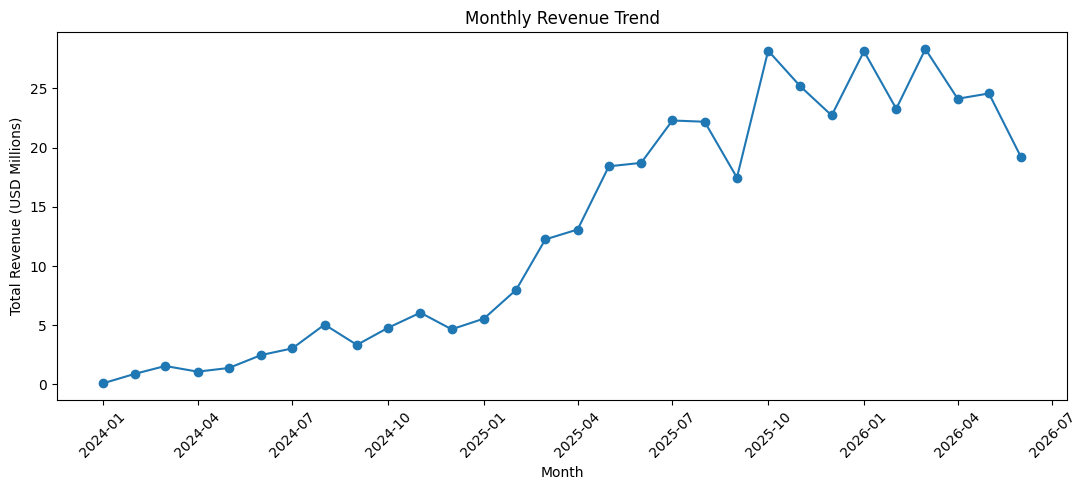

In [48]:
monthly_summary["total_revenue_musd"] = (
    monthly_summary["total_revenue_usd"] / 1_000_000
)

plt.figure(figsize=(11, 5))

plt.plot(
    monthly_summary["sale_month"],
    monthly_summary["total_revenue_musd"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue (USD Millions)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [49]:
monthly_summary.nlargest(
    5,
    "total_revenue_usd"
)[
    ["sale_month", "total_transactions", "total_units_sold", "total_revenue_usd"]
]

,sale_month,total_transactions,total_units_sold,total_revenue_usd
26,2026-03-01,531,11505,"28,328,252.14"
21,2025-10-01,446,9580,"28,187,539.49"
24,2026-01-01,527,10979,"28,140,251.25"
22,2025-11-01,493,10788,"25,167,904.53"
28,2026-05-01,461,10493,"24,577,552.13"


In [50]:
# Calculate average revenue per transaction by month
monthly_summary["avg_revenue_per_transaction"] = (
    monthly_summary["total_revenue_usd"]
    / monthly_summary["total_transactions"]
)

monthly_summary[
    [
        "sale_month",
        "total_transactions",
        "total_revenue_usd",
        "avg_revenue_per_transaction"
    ]
].head()

,sale_month,total_transactions,total_revenue_usd,avg_revenue_per_transaction
0,2024-01-01,3,"86,422.76","28,807.59"
1,2024-02-01,11,"896,181.88","81,471.08"
2,2024-03-01,15,"1,553,751.37","103,583.42"
3,2024-04-01,20,"1,076,240.24","53,812.01"
4,2024-05-01,31,"1,384,152.52","44,650.08"


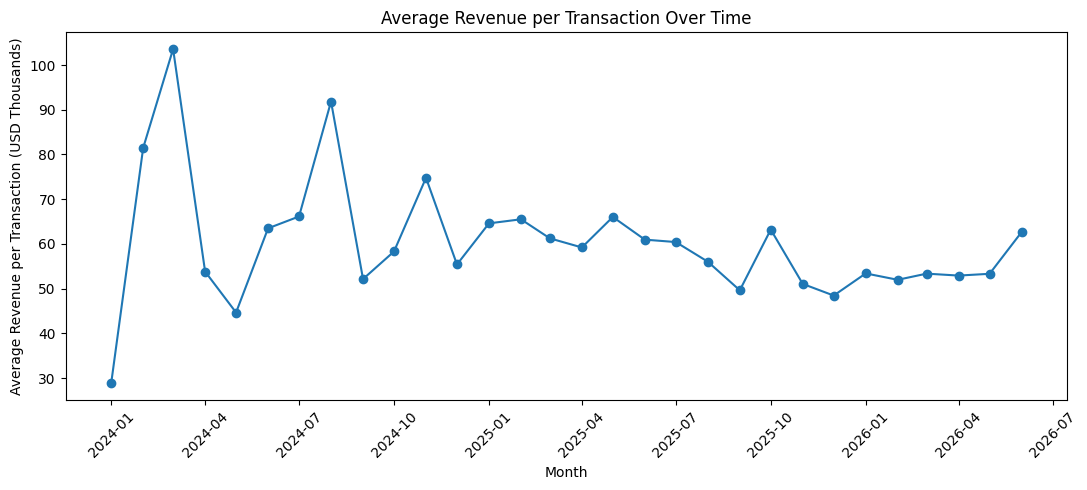

In [51]:
plt.figure(figsize=(11, 5))

plt.plot(
    monthly_summary["sale_month"],
    monthly_summary["avg_revenue_per_transaction"] / 1_000,
    marker="o"
)

plt.title("Average Revenue per Transaction Over Time")
plt.xlabel("Month")
plt.ylabel("Average Revenue per Transaction (USD Thousands)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

**Key Finding:**  
Monthly revenue increased substantially over the observed period, reaching its highest level in March 2026 at approximately USD 28.3 million. However, average revenue per transaction did not show a comparable upward trend and remained relatively stable at around USD 50K–65K during most of 2025 and 2026. This indicates that the growth in total revenue was primarily driven by increasing transaction volume rather than sustained growth in transaction value. Early-period fluctuations should be interpreted cautiously because monthly transaction counts were still relatively small.

### 5.8 Bundle Add-on Analysis

This section compares transaction value across bundle add-on categories and examines whether differences in average revenue are associated with the underlying GPU product mix.

In [52]:
# Bundle add-on performance summary
bundle_summary = (
    df_clean
    .groupby("bundle_addon")
    .agg(
        total_transactions=("sale_id", "count"),
        total_units_sold=("units_sold", "sum"),
        avg_units_per_transaction=("units_sold", "mean"),
        total_revenue_usd=("revenue_usd", "sum"),
        avg_revenue_per_transaction=("revenue_usd", "mean")
    )
    .round(2)
    .sort_values("avg_revenue_per_transaction", ascending=False)
)

bundle_summary

,total_transactions,total_units_sold,avg_units_per_transaction,total_revenue_usd,avg_revenue_per_transaction
bundle_addon,,,,,
Support Contract,368,2393,6.50,"77,301,809.05","210,059.26"
NVLink Cluster Install,168,1037,6.17,"33,500,595.53","199,408.31"
Standalone,3841,84286,21.94,"213,246,485.12","55,518.48"
Cooling Kit,598,14674,24.54,"17,455,797.73","29,190.30"
Extended Warranty,1166,28329,24.30,"31,579,152.42","27,083.32"
Software Bundle,859,21000,24.45,"22,976,612.78","26,748.09"


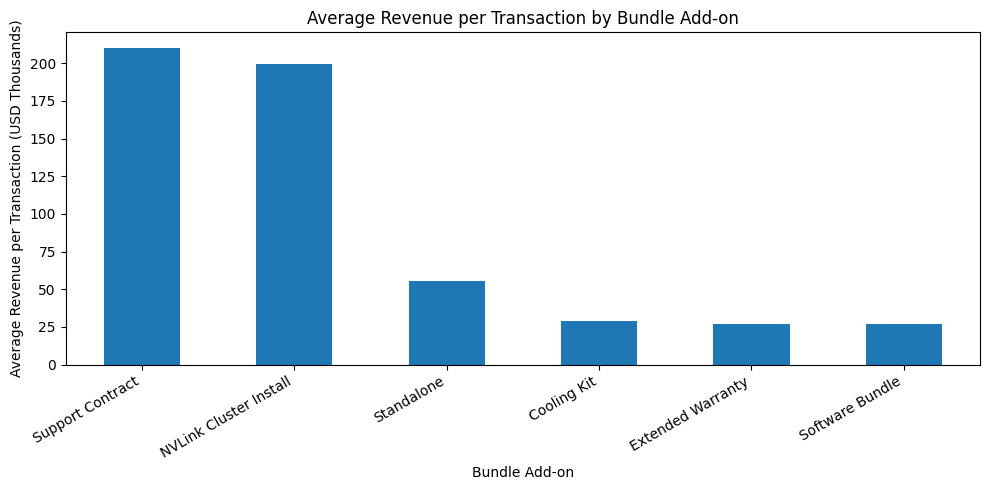

In [53]:
# Average transaction value by bundle add-on
bundle_avg_revenue = (
    bundle_summary["avg_revenue_per_transaction"] / 1_000
)

plt.figure(figsize=(10, 5))

bundle_avg_revenue.plot(kind="bar")

plt.title("Average Revenue per Transaction by Bundle Add-on")
plt.xlabel("Bundle Add-on")
plt.ylabel("Average Revenue per Transaction (USD Thousands)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.show()

**Key Finding:**  
Average transaction value varies substantially across bundle add-on categories. Support Contract and NVLink Cluster Install record much higher average transaction values than standalone purchases and consumer-oriented add-ons. However, these differences may reflect the types of GPU products associated with each bundle rather than the bundle itself.

In [54]:
# Transaction distribution by bundle add-on and GPU family
bundle_family_transactions = pd.crosstab(
    df_clean["bundle_addon"],
    df_clean["gpu_family"]
)

bundle_family_transactions

gpu_family,Consumer Gaming,Data Center AI
bundle_addon,,
Cooling Kit,598,0
Extended Warranty,1166,0
NVLink Cluster Install,0,168
Software Bundle,859,0
Standalone,3300,541
Support Contract,0,368


In [55]:
# Percentage composition by GPU family within each bundle category
bundle_family_pct = (
    bundle_family_transactions
    .div(bundle_family_transactions.sum(axis=1), axis=0)
    * 100
).round(2)

bundle_family_pct

gpu_family,Consumer Gaming,Data Center AI
bundle_addon,,
Cooling Kit,100.00,0.00
Extended Warranty,100.00,0.00
NVLink Cluster Install,0.00,100.00
Software Bundle,100.00,0.00
Standalone,85.92,14.08
Support Contract,0.00,100.00


<Figure size 1000x500 with 0 Axes>

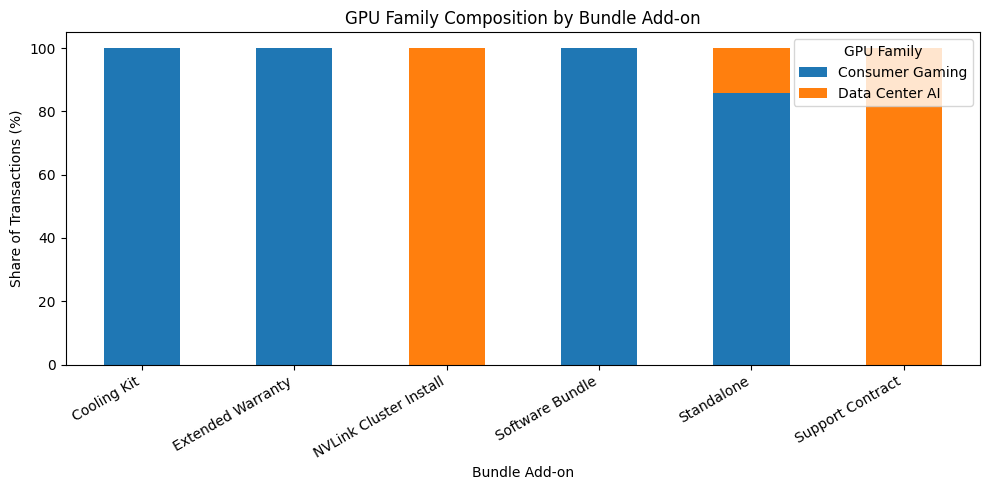

In [56]:
plt.figure(figsize=(10, 5))

bundle_family_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5)
)

plt.title("GPU Family Composition by Bundle Add-on")
plt.xlabel("Bundle Add-on")
plt.ylabel("Share of Transactions (%)")
plt.xticks(rotation=30, ha="right")
plt.legend(title="GPU Family")
plt.tight_layout()

plt.show()

**Key Finding:**  
Bundle add-on categories are strongly associated with different GPU product families. Support Contract and NVLink Cluster Install transactions consist entirely of Data Center AI products, while Cooling Kit, Extended Warranty, and Software Bundle transactions consist entirely of Consumer Gaming GPUs. Standalone transactions contain a mix of both families. Therefore, the substantially higher average transaction values observed for enterprise-oriented add-ons are primarily associated with their higher-priced Data Center AI product mix rather than evidence that the add-ons themselves increase transaction value.

### 5.9 High-Premium Transaction Analysis

This section examines transactions with price premiums above 50% to understand their revenue contribution and identify the market conditions in which these high-premium transactions are concentrated.

In [57]:
# Flag transactions with price premium above 50%
df_clean["high_premium_flag"] = (
    df_clean["price_premium_pct"] > 50
)

In [58]:
# Compare regular and high-premium transactions
high_premium_summary = (
    df_clean
    .groupby("high_premium_flag")
    .agg(
        total_transactions=("sale_id", "count"),
        total_units_sold=("units_sold", "sum"),
        total_revenue_usd=("revenue_usd", "sum"),
        avg_revenue_per_transaction=("revenue_usd", "mean"),
        avg_price_premium_pct=("price_premium_pct", "mean"),
        avg_customer_satisfaction=("customer_satisfaction_score", "mean")
    )
    .round(2)
)

high_premium_summary.index = [
    "Regular Premium",
    "High Premium (>50%)"
]

high_premium_summary

,total_transactions,total_units_sold,total_revenue_usd,avg_revenue_per_transaction,avg_price_premium_pct,avg_customer_satisfaction
Regular Premium,6741,146099,"368,555,331.41","54,673.69",13.33,4.48
High Premium (>50%),259,5620,"27,505,121.22","106,197.38",58.68,3.13


In [59]:
# Calculate transaction and revenue shares
high_premium_transactions = df_clean["high_premium_flag"].sum()

high_premium_transaction_pct = (
    high_premium_transactions / len(df_clean) * 100
)

high_premium_revenue = df_clean.loc[
    df_clean["high_premium_flag"],
    "revenue_usd"
].sum()

high_premium_revenue_pct = (
    high_premium_revenue / df_clean["revenue_usd"].sum() * 100
)

print(f"High-premium transactions : {high_premium_transactions:,}")
print(f"Transaction share        : {high_premium_transaction_pct:.2f}%")
print(f"High-premium revenue     : USD {high_premium_revenue:,.2f}")
print(f"Revenue share            : {high_premium_revenue_pct:.2f}%")

High-premium transactions : 259
Transaction share        : 3.70%
High-premium revenue     : USD 27,505,121.22
Revenue share            : 6.94%


In [60]:
# High-premium transaction distribution by stock status
high_premium_stock = (
    df_clean.loc[df_clean["high_premium_flag"]]
    ["stock_status"]
    .value_counts()
)

high_premium_stock

,count
stock_status,
Sold Out,251
Backordered,8


In [61]:
high_premium_stock_pct = (
    high_premium_stock
    / high_premium_stock.sum()
    * 100
).round(2)

high_premium_stock_pct

,count
stock_status,
Sold Out,96.91
Backordered,3.09


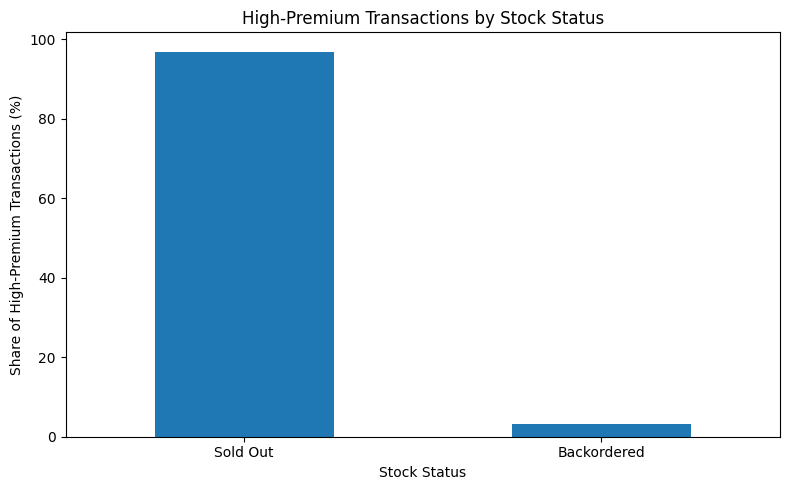

In [62]:
plt.figure(figsize=(8, 5))

high_premium_stock_pct.plot(kind="bar")

plt.title("High-Premium Transactions by Stock Status")
plt.xlabel("Stock Status")
plt.ylabel("Share of High-Premium Transactions (%)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

**Key Finding:**  
High-premium transactions represent only 3.70% of all transactions but contribute 6.94% of total revenue, with an average transaction value of approximately USD 106.2K compared with USD 54.7K for other transactions. They also record substantially lower average customer satisfaction at 3.13 versus 4.48.

High-premium activity is strongly concentrated under severe stock constraints. Approximately 96.9% of transactions with premiums above 50% occurred when products were sold out, and roughly 37.5% of all sold-out transactions exceeded the 50% premium threshold. This reinforces the strong association between product scarcity, extreme premium pricing, and lower customer satisfaction within the simulated dataset.

In [63]:
# High-premium transactions by GPU family
high_premium_gpu_family = pd.crosstab(
    df_clean["gpu_family"],
    df_clean["high_premium_flag"]
)

high_premium_gpu_family.columns = [
    "Regular Premium",
    "High Premium (>50%)"
]

high_premium_gpu_family

,Regular Premium,High Premium (>50%)
gpu_family,,
Consumer Gaming,5719,204
Data Center AI,1022,55


In [64]:
# High-premium transactions by customer segment
high_premium_segment = (
    df_clean.loc[df_clean["high_premium_flag"]]
    ["customer_segment"]
    .value_counts()
)

high_premium_segment

,count
customer_segment,
Gaming,157
Content Creation,47
Hyperscale Datacenter,25
Crypto Mining,16
AI Research/Startup,14


In [65]:
# High-premium rate within each GPU family
gpu_family_premium_rate = (
    pd.crosstab(
        df_clean["gpu_family"],
        df_clean["high_premium_flag"],
        normalize="index"
    )
    * 100
).round(2)

gpu_family_premium_rate.columns = [
    "Regular Premium (%)",
    "High Premium (>50%) (%)"
]

gpu_family_premium_rate

,Regular Premium (%),High Premium (>50%) (%)
gpu_family,,
Consumer Gaming,96.56,3.44
Data Center AI,94.89,5.11


In [66]:
# High-premium rate within each customer segment
segment_premium_rate = (
    pd.crosstab(
        df_clean["customer_segment"],
        df_clean["high_premium_flag"],
        normalize="index"
    )
    * 100
).round(2)

segment_premium_rate.columns = [
    "Regular Premium (%)",
    "High Premium (>50%) (%)"
]

segment_premium_rate.sort_values(
    "High Premium (>50%) (%)",
    ascending=False
)

,Regular Premium (%),High Premium (>50%) (%)
customer_segment,,
Crypto Mining,91.06,8.94
AI Research/Startup,95.54,4.46
Hyperscale Datacenter,95.72,4.28
Content Creation,95.95,4.05
Gaming,96.70,3.30


In [67]:
# High-premium rate within each stock status
stock_premium_rate = (
    pd.crosstab(
        df_clean["stock_status"],
        df_clean["high_premium_flag"],
        normalize="index"
    )
    * 100
).round(2)

stock_premium_rate.columns = [
    "Regular Premium (%)",
    "High Premium (>50%) (%)"
]

stock_premium_rate

,Regular Premium (%),High Premium (>50%) (%)
stock_status,,
Backordered,99.37,0.63
In Stock,100.00,0.00
Low Stock,100.00,0.00
Sold Out,62.48,37.52


## 6. Key Insights & Business Takeaways

This section summarizes the most important findings from the exploratory analysis and translates them into concise business-oriented takeaways. All findings refer to patterns within the simulated dataset and should not be interpreted as actual NVIDIA business performance.

### 6.1 Key Insights

1. **Data Center AI drives revenue despite much lower sales volume.**  
   Consumer Gaming recorded approximately 144.7K units sold compared with only 7.0K units for Data Center AI. However, Data Center AI generated approximately USD 233.1 million in revenue, exceeding Consumer Gaming at approximately USD 162.9 million. This reflects the substantially higher transaction value of enterprise GPU products.

2. **The highest-volume products are different from the highest-revenue products.**  
   RTX 5070 recorded the highest unit sales at more than 30K units, while B200 generated the highest total revenue at approximately USD 95.9 million. This demonstrates that sales volume leadership does not necessarily translate into revenue leadership.

3. **Higher price premiums are associated with lower customer satisfaction.**  
   Price premium and customer satisfaction showed a moderately strong negative correlation of approximately -0.672. Average satisfaction declined from 4.76 for Normal MSRP transactions to 3.88 for Heavy Scalping transactions.

4. **Product scarcity is strongly associated with higher premiums and lower satisfaction.**  
   In-stock products recorded an average price premium of approximately 4.1% and average satisfaction of 4.73, while sold-out products reached an average premium of approximately 45.0% and satisfaction declined to 3.52.

5. **Enterprise customer segments and channels generate substantially higher transaction values.**  
   Crypto Mining, Hyperscale Datacenter, and AI Research/Startup segments generated much higher average revenue per transaction than Gaming and Content Creation. Cloud Provider and Direct Enterprise channels were entirely composed of Data Center AI revenue, explaining their high transaction values despite relatively low transaction counts.

6. **Revenue growth over time was primarily volume-driven.**  
   Monthly revenue increased substantially during the observed period, but average revenue per transaction remained relatively stable during most of 2025 and 2026. This indicates that overall revenue growth was mainly associated with increasing transaction volume rather than sustained increases in transaction value.

7. **Extreme premium transactions are rare but economically significant.**  
   Transactions with price premiums above 50% represented only 3.70% of all transactions but contributed 6.94% of total revenue. Approximately 96.9% of these transactions occurred when products were sold out, and their average customer satisfaction was only 3.13.

### 6.2 Business Takeaways

- **Revenue strategy should consider both volume and product value.** Consumer Gaming provides substantially greater unit volume, while Data Center AI products contribute disproportionately higher revenue per transaction.

- **Inventory availability appears closely linked to pricing pressure and customer experience.** Severe stock constraints are associated with higher price premiums and lower customer satisfaction, suggesting that inventory availability is an important factor when evaluating simulated market conditions.

- **Channel performance should not be evaluated using transaction count alone.** Enterprise-oriented channels generate significantly higher transaction values because of their Data Center AI product mix.

- **Bundle performance should be interpreted alongside product mix.** Higher transaction values for Support Contract and NVLink Cluster Install are largely associated with Data Center AI products rather than evidence that the add-ons themselves increase transaction value.

- **High-premium transactions deserve monitoring despite their small share.** They contribute disproportionately to revenue while being strongly associated with sold-out conditions and substantially lower customer satisfaction.

### 6.3 Limitations

This project uses a synthetic dataset created for portfolio and analytical practice. Therefore, the results represent simulated market patterns rather than actual NVIDIA sales performance.

The analysis is primarily exploratory and observational. Relationships such as those between stock availability, price premiums, and customer satisfaction indicate associations within the dataset and should not be interpreted as causal effects.

Some categorical variables, including scalping status, were derived using predefined analytical thresholds. In addition, the earliest months contain relatively few transactions, making early-period monthly averages more sensitive to individual observations.

## 7. Export Analysis-Ready Dataset

The cleaned and feature-engineered dataset is exported for downstream SQL analysis, dashboard development, and reproducibility.

In [68]:
# Prepare analysis-ready dataset for export
df_export = df_clean.copy()

# Convert categorical feature to string for portability
df_export["scalping_status"] = df_export["scalping_status"].astype(str)

# Export cleaned dataset
OUTPUT_PATH = Path("nvidia_gpu_sales_cleaned.csv")

df_export.to_csv(
    OUTPUT_PATH,
    index=False
)

print(f"Dataset exported successfully: {OUTPUT_PATH}")
print(f"Rows    : {df_export.shape[0]:,}")
print(f"Columns : {df_export.shape[1]}")

Dataset exported successfully: nvidia_gpu_sales_cleaned.csv
Rows    : 7,000
Columns : 20


In [69]:
# Final exported dataset preview
df_export.head()

,sale_id,sale_date,gpu_model,gpu_family,launch_year,region,sales_channel,customer_segment,units_sold,msrp_usd,avg_street_price_usd,price_premium_pct,stock_status,customer_satisfaction_score,warranty_months,bundle_addon,revenue_usd,scalping_status,sale_month,high_premium_flag
0,1,2024-01-12,RTX 4090,Consumer Gaming,2022,Asia-Pacific (ex-China),Retail/Etail,Gaming,8,1599,"1,796.91",12.38,Low Stock,4.00,12,Software Bundle,"14,375.30",Slight Premium,2024-01-01,False
1,2,2024-01-18,RTX 4070 Ti Super,Consumer Gaming,2024,Asia-Pacific (ex-China),System Integrator/OEM,Content Creation,34,799,964.70,20.74,Low Stock,5.00,12,Standalone,"32,799.82",Heavy Scalping,2024-01-01,False
2,3,2024-01-20,RTX 4080 Super,Consumer Gaming,2024,North America,Retail/Etail,Gaming,30,999,"1,308.25",30.96,Sold Out,4.00,12,Standalone,"39,247.64",Heavy Scalping,2024-01-01,False
3,4,2024-02-05,H100 SXM,Data Center AI,2022,Asia-Pacific (ex-China),Direct Enterprise,Crypto Mining,5,27000,"29,202.11",8.16,Low Stock,4.50,24,Standalone,"146,010.54",Slight Premium,2024-02-01,False
4,5,2024-02-16,H100 SXM,Data Center AI,2022,Europe,Cloud Provider,Crypto Mining,9,27000,"27,778.73",2.88,In Stock,4.50,36,Standalone,"250,008.56",Normal MSRP,2024-02-01,False


In [70]:
# Final dataset validation
print("Final dataset validation")
print("-" * 30)
print(f"Rows           : {len(df_export):,}")
print(f"Columns        : {df_export.shape[1]}")
print(f"Missing values : {df_export.isnull().sum().sum():,}")
print(f"Duplicate rows : {df_export.duplicated().sum():,}")
print(f"Duplicate IDs  : {df_export['sale_id'].duplicated().sum():,}")

Final dataset validation
------------------------------
Rows           : 7,000
Columns        : 20
Missing values : 0
Duplicate rows : 0
Duplicate IDs  : 0


In [71]:
# Export full analysis-ready dataset
analysis_ready_path = Path("nvidia_gpu_sales_analysis_ready.csv")

df_export.to_csv(
    analysis_ready_path,
    index=False
)

# Export SQL-ready dataset
sql_ready_columns = [
    "sale_id",
    "sale_date",
    "gpu_model",
    "gpu_family",
    "launch_year",
    "region",
    "sales_channel",
    "customer_segment",
    "units_sold",
    "msrp_usd",
    "avg_street_price_usd",
    "price_premium_pct",
    "stock_status",
    "customer_satisfaction_score",
    "warranty_months",
    "bundle_addon",
    "revenue_usd",
    "scalping_status"
]

df_sql = df_export[sql_ready_columns].copy()

sql_ready_path = Path("nvidia_gpu_sales_sql_ready.csv")

df_sql.to_csv(
    sql_ready_path,
    index=False
)

print("Analysis-ready dataset :", analysis_ready_path)
print("Analysis-ready columns :", df_export.shape[1])

print("\nSQL-ready dataset      :", sql_ready_path)
print("SQL-ready columns      :", df_sql.shape[1])

Analysis-ready dataset : nvidia_gpu_sales_analysis_ready.csv
Analysis-ready columns : 20

SQL-ready dataset      : nvidia_gpu_sales_sql_ready.csv
SQL-ready columns      : 18
